<a href="https://colab.research.google.com/github/rahafalnjjar49-cloud/Diabetes-prediction/blob/main/Diabetes_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix)


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes.csv


In [ ]:
df=pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
print ("Class distribution (Outcome)")
print (df['Outcome'].value_counts())

Class distribution (Outcome)
Outcome
0    500
1    268
Name: count, dtype: int64


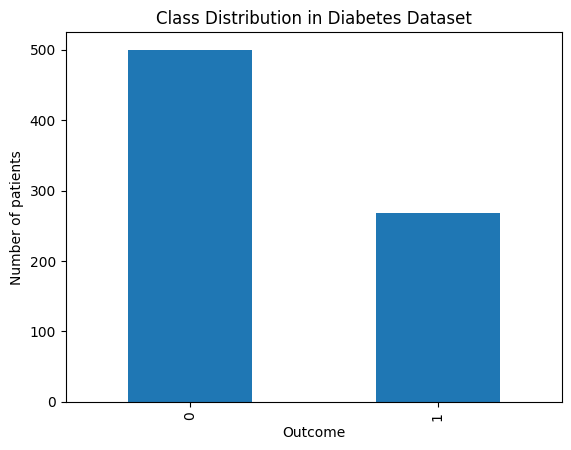

In [ ]:
df["Outcome"].value_counts().plot(kind="bar")
plt.xlabel("Outcome")
plt.ylabel("Number of patients")
plt.title("Class Distribution in Diabetes Dataset")
plt.show()

In [ ]:
correlation= df.corr()["Outcome"].sort_values(ascending=False)
print("Correlation of Features with Outcome:")
print(correlation)

Correlation of Features with Outcome:
Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


In [ ]:
corr_matrix= df.corr().round(2)
print(corr_matrix)

                          Pregnancies  Glucose  BloodPressure  SkinThickness  \
Pregnancies                      1.00     0.13           0.14          -0.08   
Glucose                          0.13     1.00           0.15           0.06   
BloodPressure                    0.14     0.15           1.00           0.21   
SkinThickness                   -0.08     0.06           0.21           1.00   
Insulin                         -0.07     0.33           0.09           0.44   
BMI                              0.02     0.22           0.28           0.39   
DiabetesPedigreeFunction        -0.03     0.14           0.04           0.18   
Age                              0.54     0.26           0.24          -0.11   
Outcome                          0.22     0.47           0.07           0.07   

                          Insulin   BMI  DiabetesPedigreeFunction   Age  \
Pregnancies                 -0.07  0.02                     -0.03  0.54   
Glucose                      0.33  0.22          

<Axes: >

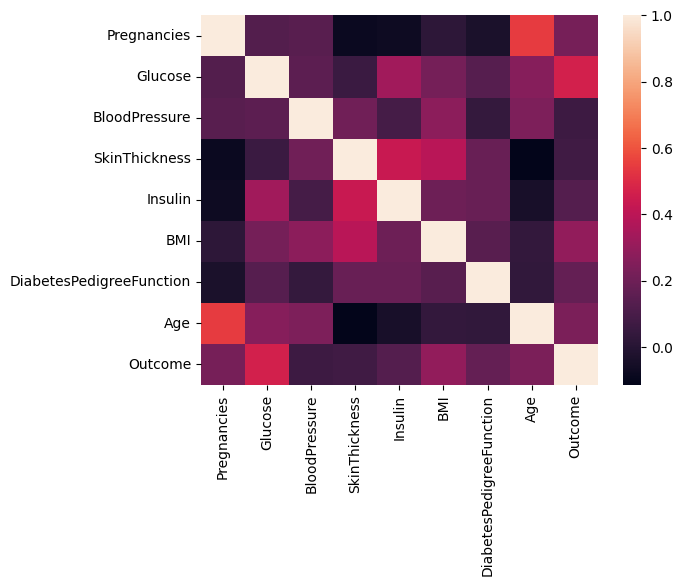

In [ ]:
sns.heatmap(df.corr())

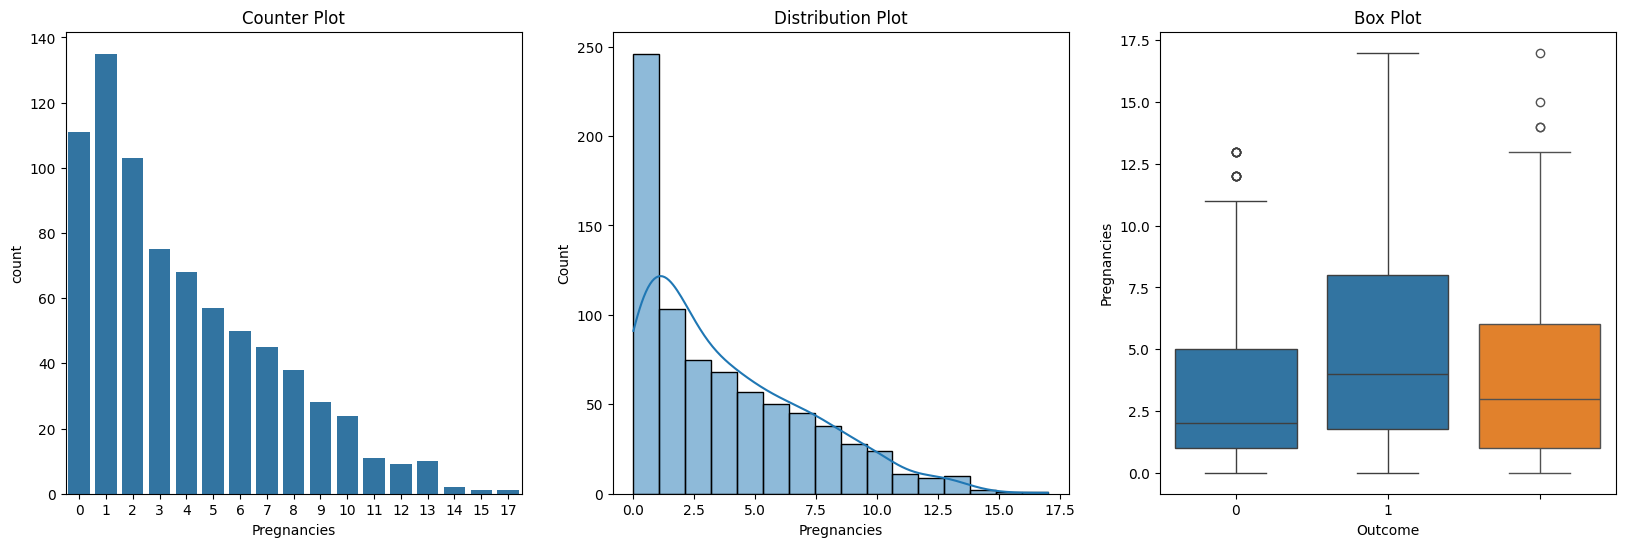

In [ ]:
plt.figure(figsize=(20, 6))

plt.subplot(1, 3, 1)
plt.title("Counter Plot")
sns.countplot(x=df['Pregnancies'])


plt.subplot(1, 3, 2)
plt.title("Distribution Plot")
sns.histplot(df['Pregnancies'], kde=True)

plt.subplot(1, 3, 3)
plt.title("Box Plot of Pregnancies by Outcome")
sns.boxplot(x='Outcome', y='Pregnancies', data=df)

plt.subplot(1, 3, 3)
plt.title("Box Plot")
sns.boxplot(y=df['Pregnancies'])

plt.show()

<Axes: ylabel='Age'>

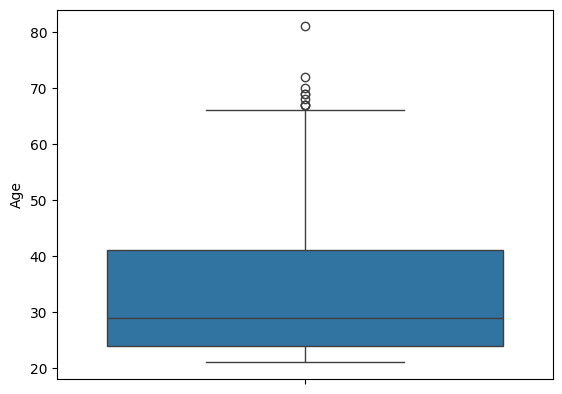

In [ ]:
sns.boxplot(df.Age)

In [ ]:
x=df.drop('Outcome',axis=1)
y=df['Outcome']

In [ ]:
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.2,random_state=42)


**Naive Bayes**

In [ ]:
nb_classifier = GaussianNB()

In [ ]:
nb_classifier.fit(x_train, y_train)

GaussianNB()

In [ ]:
y_pred_nb = nb_classifier.predict(x_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))
print("Classification Report:")
print(classification_report(y_test, y_pred_nb))

Accuracy: 0.7662337662337663
Confusion Matrix:
[[79 20]
 [16 39]]
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.80      0.81        99
           1       0.66      0.71      0.68        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



**Decision Tree Classifier**

In [ ]:
classifier= DecisionTreeClassifier()
classifier.fit(x_train,y_train)
y_pred_t=classifier.predict(x_test)


In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_t))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_t))
print("Classification Report:")
print(classification_report(y_test, y_pred_t))

Accuracy: 0.7597402597402597
Confusion Matrix:
[[76 23]
 [14 41]]
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.77      0.80        99
           1       0.64      0.75      0.69        55

    accuracy                           0.76       154
   macro avg       0.74      0.76      0.75       154
weighted avg       0.77      0.76      0.76       154



**Support Vector machine (SVM)**

In [ ]:
clf=SVC()
clf.fit(x_train,y_train)
y_pred_s=clf.predict(x_test)
y_pred_s=clf.predict(x_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_s))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_s))
print("Classification Report:")
print(classification_report(y_test, y_pred_s))

Accuracy: 0.7662337662337663
Confusion Matrix:
[[87 12]
 [24 31]]
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.88      0.83        99
           1       0.72      0.56      0.63        55

    accuracy                           0.77       154
   macro avg       0.75      0.72      0.73       154
weighted avg       0.76      0.77      0.76       154



**Random Forest**

In [ ]:
rfc=RandomForestClassifier()
rfc.fit(x_train,y_train)
y_pred_r=rfc.predict(x_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_r))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_r))
print("Classification Report:")
print(classification_report(y_test, y_pred_r))

Accuracy: 0.7337662337662337
Confusion Matrix:
[[78 21]
 [20 35]]
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.79      0.79        99
           1       0.62      0.64      0.63        55

    accuracy                           0.73       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154



**XGboost**

In [ ]:
gb=GradientBoostingClassifier()
gb.fit(x_train,y_train)
y_pred_g=gb.predict(x_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_g))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_g))
print("Classification Report:")
print(classification_report(y_test, y_pred_g))

Accuracy: 0.7402597402597403
Confusion Matrix:
[[77 22]
 [18 37]]
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.78      0.79        99
           1       0.63      0.67      0.65        55

    accuracy                           0.74       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.75      0.74      0.74       154



In [ ]:
import joblib

joblib.dump(nb_classifier, "nb.pkl")
joblib.dump(classifier, "dt.pkl")
joblib.dump(clf, "svm.pkl")
joblib.dump(rfc, "rf.pkl")
joblib.dump(gb, "gb.pkl")

print("Models saved successfully")

Models saved successfully


In [ ]:
%%writefile app.py
import streamlit as st
import numpy as np
import joblib

nb_classifier = joblib.load("nb.pkl")
classifier    = joblib.load("dt.pkl")
clf           = joblib.load("svm.pkl")
rfc           = joblib.load("rf.pkl")
gb            = joblib.load("gb.pkl")

models = {
    "Naive Bayes": nb_classifier,
    "Decision Tree": classifier,
    "SVM": clf,
    "Random Forest": rfc,
    "Gradient Boosting": gb
}

print("Models ready")

st.title("Diabetes Prediction System")
st.sidebar.header("Patient Data")
Pregnancies = st.sidebar.number_input("Pregnancies",0,20,1)

Glucose = st.sidebar.number_input("Glucose",0,200,120)

BloodPressure = st.sidebar.number_input("Blood Pressure",0,150,70)

SkinThickness = st.sidebar.number_input("Skin Thickness",0,100,20)

Insulin = st.sidebar.number_input("Insulin",0,900,80)

BMI = st.sidebar.number_input("BMI",0.0,70.0,25.0)

DiabetesPedigreeFunction = st.sidebar.number_input(
"Diabetes Pedigree Function",
0.0,3.0,0.5
)

Age = st.sidebar.number_input("Age",1,120,30)



model_name = st.selectbox(
"Choose Model",
models.keys()
)



if st.button("Predict"):


    data = np.array([
        Pregnancies,
        Glucose,
        BloodPressure,
        SkinThickness,
        Insulin,
        BMI,
        DiabetesPedigreeFunction,
        Age
    ]).reshape(1,-1)


    model = models[model_name]


    prediction = model.predict(data)


    if prediction[0] == 1:

        st.error("Diabetes detected")

    else:

        st.success("No Diabetes")


Writing app.py


In [ ]:
!pip install streamlit pyngrok
!pkill -f streamlit
!nohup streamlit run app.py --server.port 8501 > streamlit.log 2>&1 &
from pyngrok import ngrok

ngrok.kill()
!ngrok config add-authtoken 32K4OXPeF0KrZc32p1D8CZWbOmi_2LvuHtQTsCg6kcHqKyLpf
tunnel = ngrok.connect(8501)
print(tunnel.public_url)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 70.0 MB/s eta 0:00:00
Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml
https://0217-34-19-36-171.ngrok-free.app
